<a href="https://colab.research.google.com/github/Srivaibhav4014e/Data-science-/blob/main/K-Means%20clustering%20algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

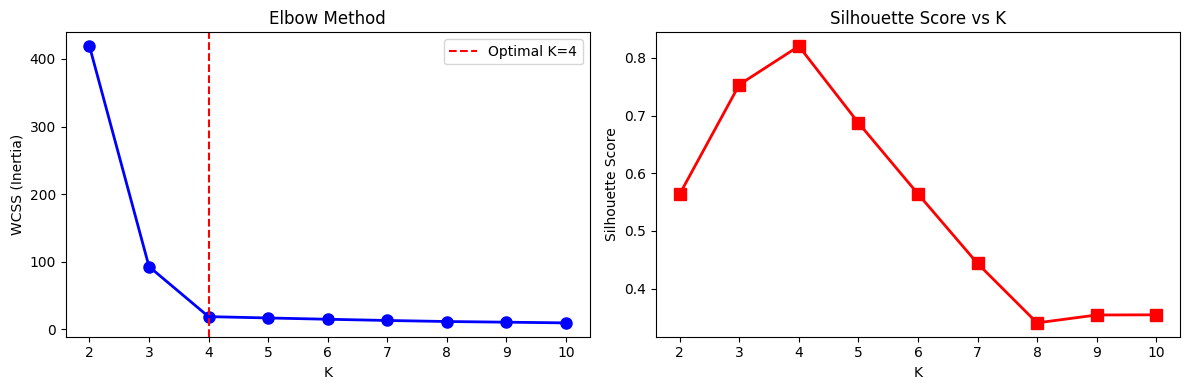

WCSS: 18.84
Silhouette Score: 0.8202
Cluster 0: 100 points
Cluster 1: 100 points
Cluster 2: 100 points
Cluster 3: 100 points


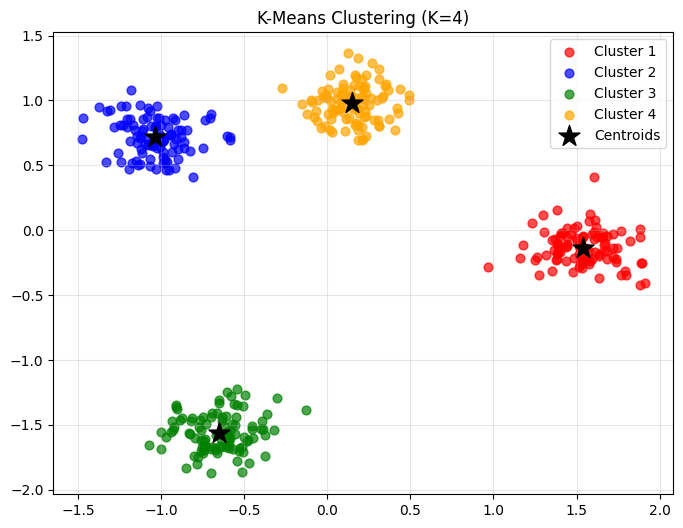


Iris Clustering Accuracy (approx): 0.4599


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

# ── Generate Data ────────────────────────────────
X, y_true = make_blobs(n_samples=400, centers=4,
                        cluster_std=0.9, random_state=42)
X = StandardScaler().fit_transform(X)  # Always scale!

# ── Elbow Method ─────────────────────────────────
wcss = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++',
                max_iter=300, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,4))
ax1.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('K'); ax1.set_ylabel('WCSS (Inertia)')
ax1.set_title('Elbow Method')
ax1.axvline(4, color='red', linestyle='--', label='Optimal K=4')
ax1.legend()

ax2.plot(K_range, sil_scores, 'rs-', linewidth=2, markersize=8)
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs K')
plt.tight_layout(); plt.show()

# ── Train with Optimal K ─────────────────────────
K = 4
kmeans = KMeans(n_clusters=K, init='k-means++',
                max_iter=300, n_init=10, random_state=42)
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

print(f'WCSS: {kmeans.inertia_:.2f}')
print(f'Silhouette Score: {silhouette_score(X,labels):.4f}')
for i in range(K):
    count = np.sum(labels==i)
    print(f'Cluster {i}: {count} points')

# ── Visualize Clusters ───────────────────────────
colors = ['red','blue','green','orange']
plt.figure(figsize=(8,6))
for i in range(K):
    mask = labels==i
    plt.scatter(X[mask,0], X[mask,1], c=colors[i],
                s=40, alpha=0.7, label=f'Cluster {i+1}')
plt.scatter(centers[:,0], centers[:,1], c='black',
            s=250, marker='*', label='Centroids', zorder=5)
plt.title(f'K-Means Clustering (K={K})')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# ── K-Means on Iris (Real Dataset) ───────────────
iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)
km_iris = KMeans(n_clusters=3, random_state=42, n_init=10)
iris_labels = km_iris.fit_predict(X_iris)
print('\nIris Clustering Accuracy (approx):',
      silhouette_score(X_iris, iris_labels).round(4))